In [1]:
import torch
import torch.nn as nn
from networks import FullyConnectedNN, NoisyFullyConnectedNN, FixNoiseFullyConnectedNN, DropoutFullyConnectedNN
import os
import pandas as pd
import numpy as np
from utils import *
import shutil
import itertools
from config import configs
from matplotlib import pyplot as plt
from tqdm import tqdm
import math
plt.style.use('default')

{'datasets': ['protein-tertiary-structure'], 'models': ['noisyFCN'], 'optimizer_name': 'Adam', 'hyperparam_eval_interval': 10, 'patience': 3, 'global_max_epochs': 2000, 'dropout_probs': [0.2, 0.1, 0.05, 0.01, 0.005, 0.001], 'fix_noiselevels': [0.001, 0.005, 0.01, 0.05, 0.1], 'init_noiselevels': [0.001, 0.005, 0.01, 0.05, 0.1], 'batch_sizes': [32], 'batch_sizes_specific': {'energy': [32]}, 'weight_decays': [0.01], 'dropout_batch_size': 32, 'n_hidden': 2, 'nonlinearity': 'relu', 'learning_rates': [0.002], 'mc_samples': 500, 'num_units': 50, 'num_units_specific': {'protein-tertiary-structure': 100}, 'normalize_X': True, 'normalize_y': True, 'n_folds': 5, 'inverted_cv_fraction': 5}


In [2]:
def def_optm(optimizer_name, normal_param, alpha_param, learning_rate, momentum=0, weight_decay=None):
    if optimizer_name == "SGD":
        print("using SGD as optimizer")
        optimizer = torch.optim.SGD([
                                    {'params': normal_param},
                                    {'params': alpha_param, 'weight_decay': 0}
                                    ],
                                    lr=learning_rate,
                                    momentum=momentum, weight_decay=weight_decay,
                                    nesterov=True)

    elif optimizer_name == "Adam":
        print("using Adam as optimizer")
        optimizer = torch.optim.Adam([
                                    {'params': normal_param},
                                    {'params': alpha_param, 'weight_decay': 0}
                                    ],
                                    lr=learning_rate,
                                    weight_decay=weight_decay)
    elif optimizer_name == "RMSprop":
        print("using RMSprop as optimizer")
        optimizer = torch.optim.RMSprop([
                                    {'params': normal_param},
                                    {'params': alpha_param, 'weight_decay': 0}
                                    ],
                                    lr=learning_rate, alpha=0.99, eps=1e-08, weight_decay=weight_decay, momentum=0)
    return optimizer

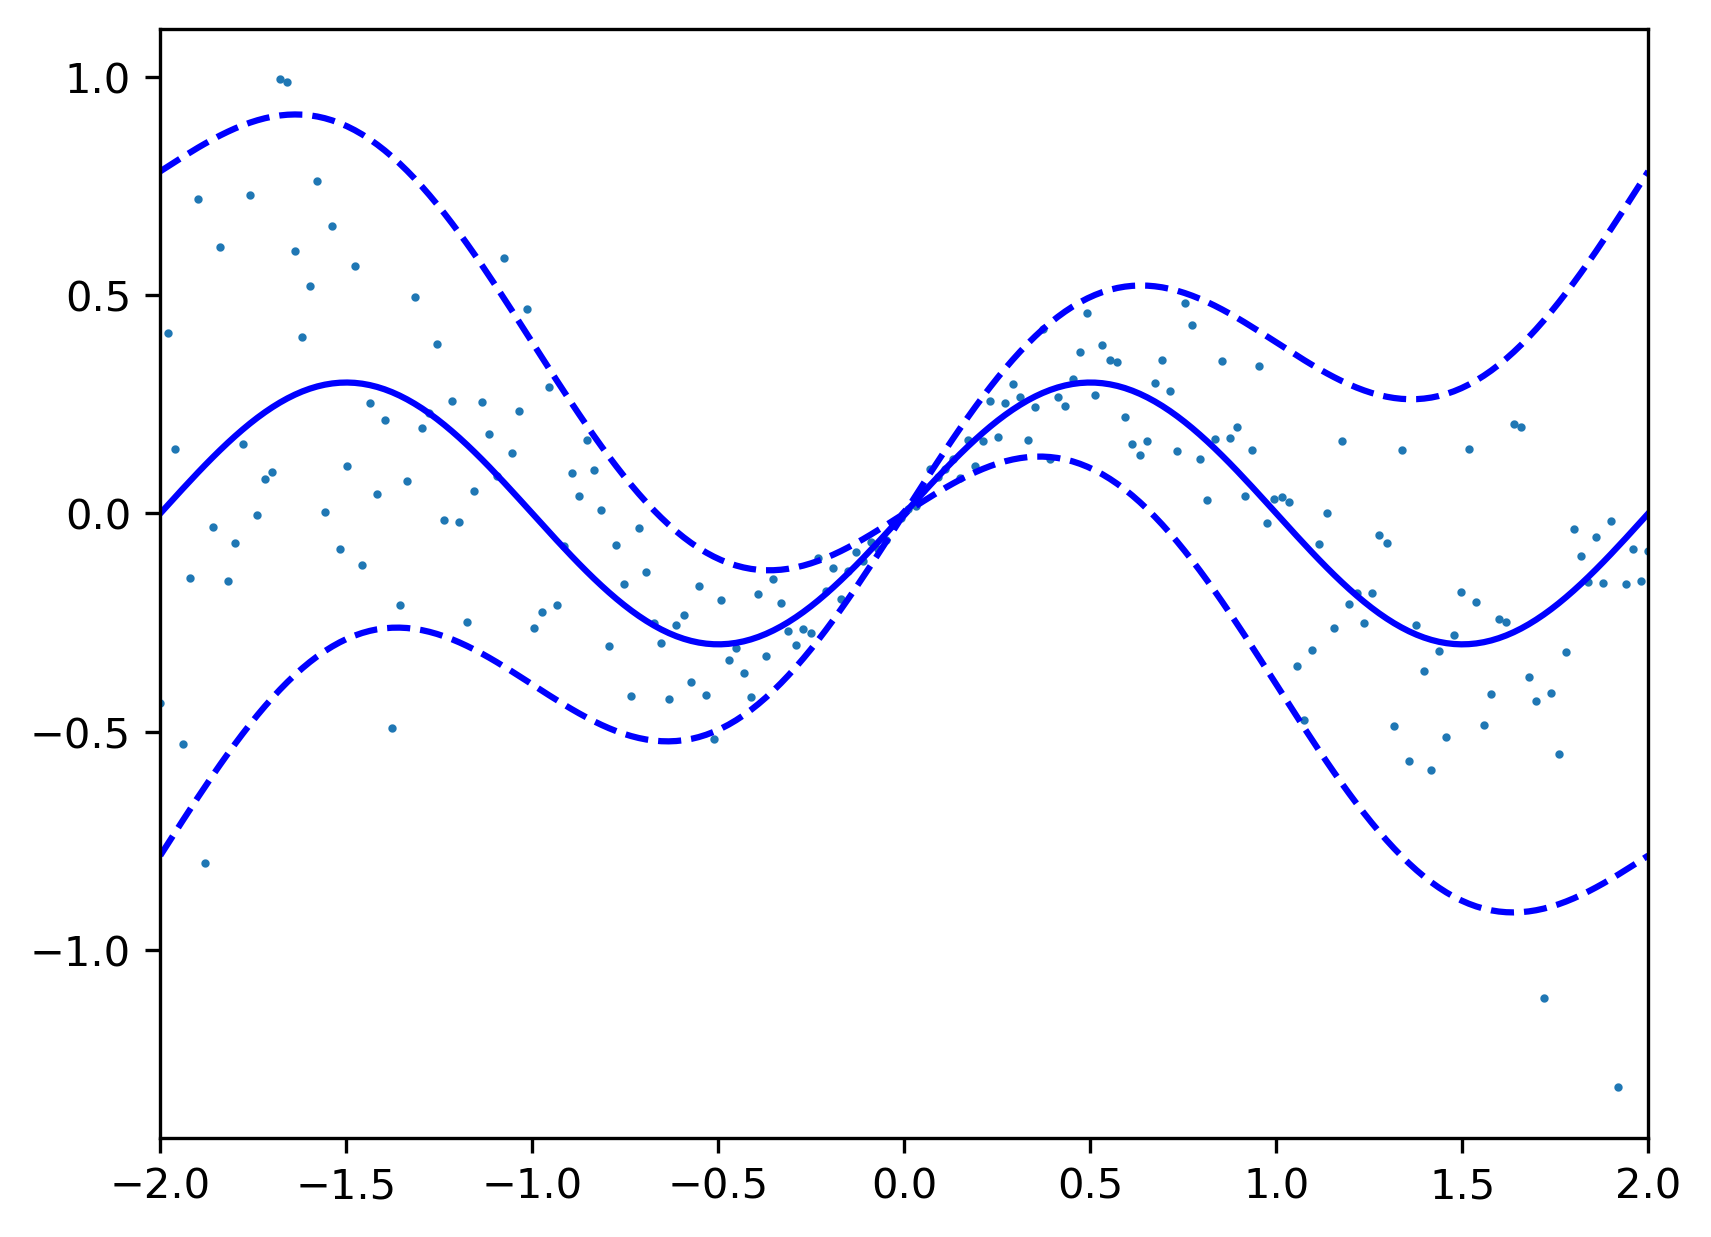

In [3]:
np.random.seed(123)
# 定义方程
def equation(x):
    epsilon = np.random.normal(0, np.abs(x))
    return 0.3 * np.sin(x*np.pi) + 0.2 * epsilon

num_samples = 200
# 生成 x 值
x_values = np.linspace(-2, 2, num_samples)

# 计算对应的 y 值
y_values = equation(x_values)

y1 = 0.3 * np.sin(x_values*np.pi)
y2 = 0.3 * np.sin(x_values*np.pi) + 1.96*0.2*np.abs(x_values)
y3 = 0.3 * np.sin(x_values*np.pi) - 1.96*0.2*np.abs(x_values)

plt.figure(dpi=300)
plt.scatter(x_values, y_values, s=1)
plt.plot(x_values, y1, color='blue')
plt.plot(x_values, y2, color='blue', linestyle='dashed')
plt.plot(x_values, y3, color='blue', linestyle='dashed')
plt.xlim(-2, 2)
plt.show()

In [4]:
x = x_values[:, np.newaxis]
y = y_values[:, np.newaxis]

In [5]:
X = torch.tensor(x, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)
train_data = torch.utils.data.TensorDataset(X, y)
batch_size = len(X)
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=False, num_workers=4)

In [6]:
# ['FCN', 'noisyFCN', 'fixnoiseFCN', 'dropoutFCN']
model_name = "fixnoiseFCN"
input_size = X.shape[1]
hidden_sizes = [100]
output_size = 1
init_noiselevel, fix_noiselevel, dropout_prob = 0.3, 0.05, 0.5

In [7]:
model = def_model(model_name, input_size, hidden_sizes, output_size, init_noiselevel, fix_noiselevel, dropout_prob)

model_name fixnoiseFCN


In [8]:
normal_param = [
    param for name, param in model.named_parameters()
    if (not 'alpha_' in name and not 'alphafix_' in name)
] # this is the parameters do not contain noise scale coefficient
alpha_param = [
    param for name, param in model.named_parameters()
    if 'alpha_' in name
]
criterion = nn.MSELoss()
use_cuda = torch.cuda.is_available()
if use_cuda:
    model.cuda()
    criterion.cuda()

learning_rate = 0.005
momentum = 0.9
weight_decay = 0
optimizer_name = "Adam"
optimizer = def_optm(optimizer_name, normal_param, alpha_param, learning_rate, weight_decay=weight_decay)

using Adam as optimizer


In [9]:
global_max_epochs = 500

In [10]:
train_losses = []
for epoch in tqdm(range(global_max_epochs)):
    train_loss = train(model=model, train_loader=train_loader, optimizer=optimizer, criterion=criterion, use_cuda=use_cuda)
    print('epoch: {}, train_loss: {:.4f}'.format(epoch, train_loss))
    train_losses.append(train_loss)

  0%|          | 1/500 [00:01<15:59,  1.92s/it]

epoch: 0, train_loss: 0.1485


  0%|          | 2/500 [00:02<11:01,  1.33s/it]

epoch: 1, train_loss: 0.1086


  1%|          | 3/500 [00:04<11:44,  1.42s/it]

...

epoch: 497, train_loss: 0.0687


100%|█████████▉| 499/500 [10:37<00:00,  1.01it/s]

epoch: 498, train_loss: 0.0596


100%|██████████| 500/500 [10:38<00:00,  1.28s/it]

epoch: 499, train_loss: 0.0634


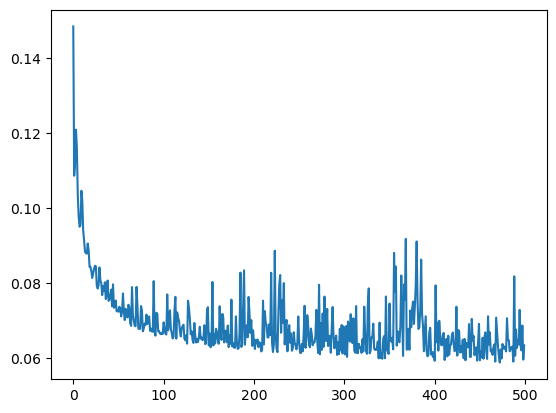

In [11]:
plt.plot(train_losses)

In [12]:
def validate(model, val_loader, criterion, test_times=100, use_cuda=False):
    model.eval()
    if 'Dropout' in model._get_name():
        recursive_module_iteration(model)
    losses = AverageMeter()
    with torch.no_grad():
        var_outputs_all = []
        pred_all = []
        for inputs, labels in val_loader:
            outputs = torch.zeros((inputs.shape[0], 1, test_times))
            if use_cuda:
                labels = labels.cuda()
                inputs = inputs.cuda()
                outputs = outputs.cuda()
            # compute output
            for i in range(test_times):
                output = model(inputs)
                outputs[:, :, i] = output
            avg_outputs = torch.mean(outputs, dim=2)
            var_outputs = torch.sum(torch.var(outputs, dim=2), dim=-1)
            loss = criterion(avg_outputs, labels)
            losses.update(loss.item(), inputs.size(0))
            if use_cuda:
                var_outputs = var_outputs.cpu()
                avg_outputs = avg_outputs.cpu()
            var_outputs = var_outputs.numpy().tolist()
            var_outputs_all.extend(var_outputs)
            avg_outputs = avg_outputs.numpy().tolist()
            pred_all.extend(avg_outputs)
            
    return losses.avg, var_outputs_all, pred_all

In [13]:
loss, var_all, pred_all = validate(model, train_loader, criterion, test_times=500, use_cuda=use_cuda)

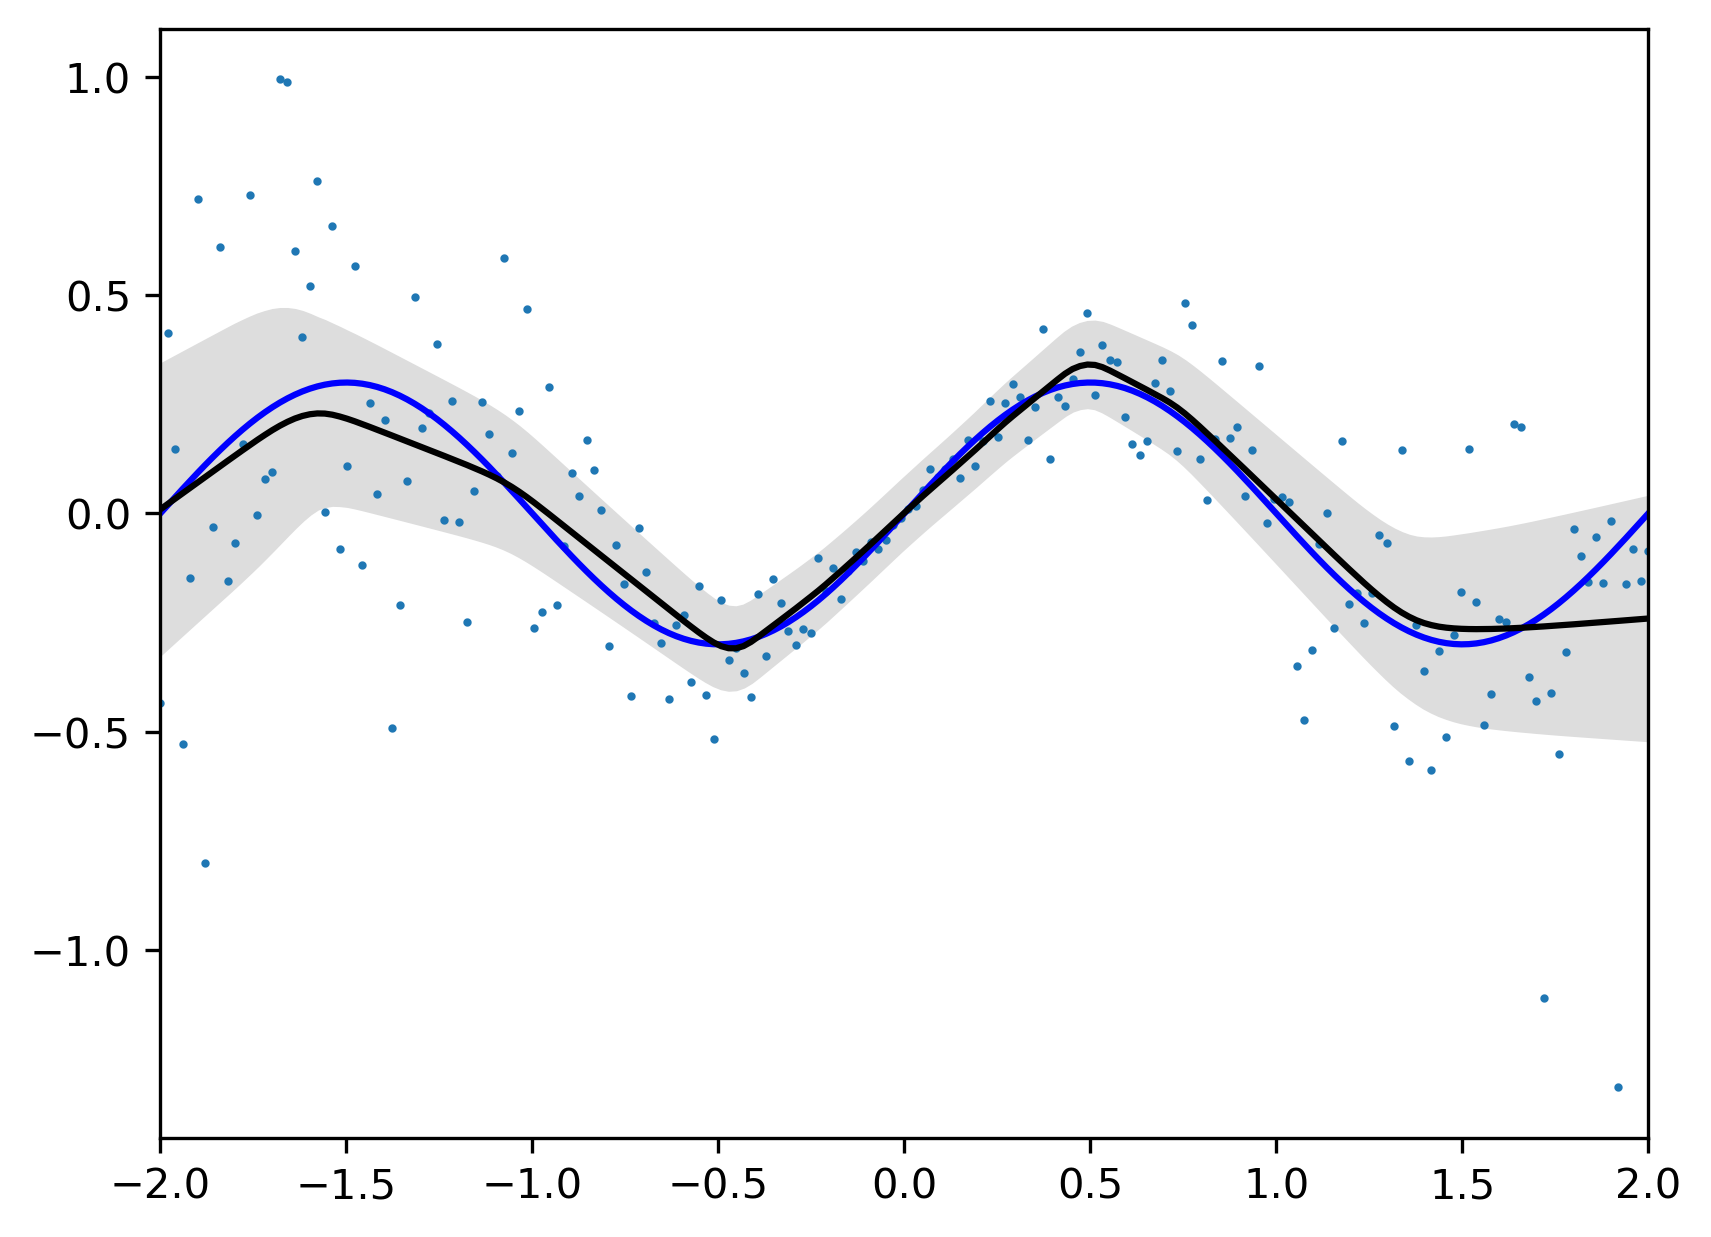

In [14]:
plt.figure(dpi=300)
n_std_dev = 3
std = np.sqrt(var_all)
pred = np.asarray(pred_all).flatten()
plt.gca().fill_between(x_values, pred-n_std_dev*std, pred+n_std_dev*std,
                           color="#dddddd")
                           
plt.scatter(x_values, y_values, s=1)
plt.plot(x_values, y1, color='blue')
# plt.plot(x_values, y2, color='blue', linestyle='dashed')
# plt.plot(x_values, y3, color='blue', linestyle='dashed')
plt.plot(x_values, pred, color='black')
plt.xlim(-2, 2)
plt.show()


In [15]:
import tensorflow as tf
MSE = np.mean((y_values-pred)**2)
MSLL = mean_standardized_log_loss(y_values, pred, std, sample_weight=None, multioutput="uniform_average", squared=True)

# hyperparameters
lambda_ = 0.01 # lambda in loss fn
alpha_ = 0.05  # capturing (1-alpha)% of samples
soften_ = 160.
n_ = batch_size # batch size

# define loss fn
def qd_objective(y_true, y_pred):
    '''Loss_QD-soft, from algorithm 1'''
    y_u = y_pred[:,1]
    y_l = y_pred[:,0]
    
    K_HU = tf.maximum(0.,tf.sign(y_u - y_true))
    K_HL = tf.maximum(0.,tf.sign(y_true - y_l))
    K_H = tf.multiply(K_HU, K_HL)
    
    K_SU = tf.sigmoid(soften_ * (y_u - y_true))
    K_SL = tf.sigmoid(soften_ * (y_true - y_l))
    K_S = tf.multiply(K_SU, K_SL)
    
    MPIW_c = tf.reduce_sum(tf.multiply((y_u - y_l),K_H))/tf.reduce_sum(K_H)
    PICP_H = tf.reduce_mean(K_H)
    PICP_S = tf.reduce_mean(K_S)
    
    Loss_H = MPIW_c + lambda_ * n_ / (alpha_*(1-alpha_)) * tf.maximum(0.,(1-alpha_) - PICP_H)
    Loss_S = MPIW_c + lambda_ * n_ / (alpha_*(1-alpha_)) * tf.maximum(0.,(1-alpha_) - PICP_S)
    
    return Loss_H, Loss_S, MPIW_c, PICP_H

pred_interval = np.stack((pred-n_std_dev*std, pred+n_std_dev*std), axis=1)
loss_qd_H, loss_qd_S, MPIW, PICP = qd_objective(y1, pred_interval)
loss_qd_H2, loss_qd_S2, MPIW2, PICP2 = qd_objective(y_values, pred_interval)

print("MSE={:.4g}, MSLL={:.4g}, loss_qd={:.4g}, {:.4g}, MPIW={:.4g}, PICP={:.4g}, loss_qd2={:.4g}, {:.4g}, MPIW2={:.4g}, PCIP2={:.4g}".format(MSE, MSLL, loss_qd_H, loss_qd_S, MPIW, PICP, loss_qd_H2, loss_qd_S2, MPIW2, PICP2))

2025-01-07 16:04:13.032739: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-07 16:04:13.046046: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-01-07 16:04:13.061700: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-01-07 16:04:13.066461: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-07 16:04:13.078894: I tensorflow/core/platform/cpu_feature_guar

first_term -2.108965187027831
second_term 6.911832043818992
MSE=0.05918, MSLL=4.803, loss_qd=0.3192, 0.3192, MPIW=0.3192, PICP=1, loss_qd2=13.36, 13.51, MPIW2=0.3043, PCIP2=0.64


2025-01-07 16:04:14.962614: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2343] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [16]:
fix_noiselevel

0.05